# EDA — PPE Dataset v6

## Detecção e Segmentação de Pessoas e Equipamentos de Proteção Individual

Este notebook realiza a Análise Exploratória dos Dados (EDA) do dataset PPE v6,
utilizado no projeto de Visão Computacional.

Objetivos:
- verificar quantidade de imagens;
- analisar distribuição das classes;
- avaliar possível desbalanceamento;
- verificar resolução das imagens;
- analisar condições de iluminação;
- visualizar exemplos das imagens e anotações.

**Instalar as bibliotecas**

In [5]:
!pip install -q ultralytics pyyaml opencv-python matplotlib pandas seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.8 MB/s eta 0:00:00


In [6]:
import os
import zipfile
import yaml
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter
from google.colab import files

**Enviar o ZIP**

In [7]:
uploaded = files.upload()

Saving PPE.v6i.yolov8.zip to PPE.v6i.yolov8.zip


In [8]:
zip_file = list(uploaded.keys())[0]

print("Arquivo recebido:")
print(zip_file)

Arquivo recebido:
PPE.v6i.yolov8.zip


**Descompactar o dataset**

In [9]:
dataset_dir = "/content/PPE_dataset"

os.makedirs(dataset_dir, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset descompactado em:")
print(dataset_dir)

Dataset descompactado em:
/content/PPE_dataset


In [10]:
for root, dirs, files_list in os.walk(dataset_dir):
    level = root.replace(dataset_dir, '').count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

PPE_dataset/
  test/
    labels/
    images/
  valid/
    labels/
    images/
  train/
    labels/
    images/


**Ler o data.yaml**

In [11]:
yaml_path = os.path.join(dataset_dir, "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 5, 'names': ['person', 'with-helmet', 'with-suit', 'without-helmet', 'without-suit'], 'roboflow': {'workspace': 'ppe-656ud', 'project': 'ppe-fq2dk', 'version': 6, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/ppe-656ud/ppe-fq2dk/dataset/6'}}


In [12]:
class_names = data["names"]

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "->", name)

Classes:
0 -> person
1 -> with-helmet
2 -> with-suit
3 -> without-helmet
4 -> without-suit


**EDA 1 — quantidade de imagens por conjunto**

In [13]:
splits = {
    "train": "train",
    "valid": "valid",
    "test": "test"
}

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

split_counts = {}

for split_name, folder_name in splits.items():

    image_dir = os.path.join(dataset_dir, folder_name, "images")

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith(image_extensions)
    ]

    split_counts[split_name] = len(images)

split_counts

{'train': 1617, 'valid': 75, 'test': 44}

In [15]:
df_splits = pd.DataFrame(
    list(split_counts.items()),
    columns=["Conjunto", "Quantidade"]
)

df_splits

,Conjunto,Quantidade
0,train,1617
1,valid,75
2,test,44


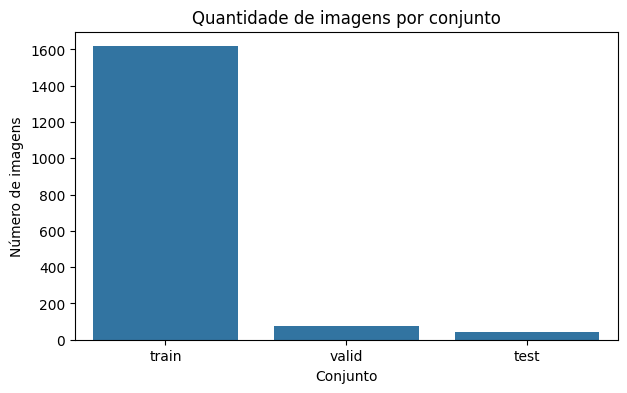

In [16]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=df_splits,
    x="Conjunto",
    y="Quantidade"
)

plt.title("Quantidade de imagens por conjunto")
plt.xlabel("Conjunto")
plt.ylabel("Número de imagens")

plt.show()

**EDA 2 — quantidade de objetos por classe**

In [17]:
class_counts = Counter()

for split_name, folder_name in splits.items():

    labels_dir = os.path.join(dataset_dir, folder_name, "labels")

    for label_file in os.listdir(labels_dir):

        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            if line.strip():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

In [18]:
df_classes = pd.DataFrame({
    "Classe": [
        class_names[i] for i in range(len(class_names))
    ],
    "Quantidade": [
        class_counts[i] for i in range(len(class_names))
    ]
})

df_classes

,Classe,Quantidade
0,person,3541
1,with-helmet,2466
2,with-suit,3101
3,without-helmet,1079
4,without-suit,272


**Gráfico da distribuição das classes**

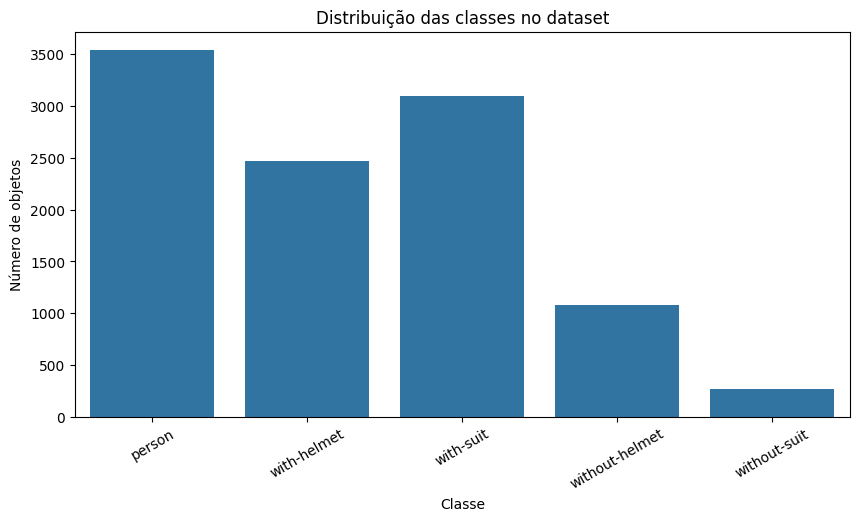

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_classes,
    x="Classe",
    y="Quantidade"
)

plt.title("Distribuição das classes no dataset")
plt.xlabel("Classe")
plt.ylabel("Número de objetos")

plt.xticks(rotation=30)

plt.show()

In [20]:
total_objects = df_classes["Quantidade"].sum()

df_classes["Percentual"] = (
    df_classes["Quantidade"] / total_objects * 100
)

df_classes

,Classe,Quantidade,Percentual
0,person,3541,33.856009
1,with-helmet,2466,23.577780
2,with-suit,3101,29.649106
3,without-helmet,1079,10.316474
4,without-suit,272,2.600631


**Calcular o percentual de cada**

In [21]:
df_classes["Percentual"] = df_classes["Percentual"].round(2)

df_classes

,Classe,Quantidade,Percentual
0,person,3541,33.86
1,with-helmet,2466,23.58
2,with-suit,3101,29.65
3,without-helmet,1079,10.32
4,without-suit,272,2.60


**Medir o desbalanceamento**

In [22]:
max_count = df_classes["Quantidade"].max()
min_count = df_classes["Quantidade"].min()

imbalance_ratio = max_count / min_count

print(f"Maior classe: {max_count}")
print(f"Menor classe: {min_count}")
print(f"Razão maior/menor: {imbalance_ratio:.2f}")

Maior classe: 3541
Menor classe: 272
Razão maior/menor: 13.02


**EDA 3 — resolução das imagens**

In [23]:
resolution_data = []

for split_name, folder_name in splits.items():

    image_dir = os.path.join(dataset_dir, folder_name, "images")

    for image_file in os.listdir(image_dir):

        if not image_file.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(image_dir, image_file)

        with Image.open(image_path) as img:
            width, height = img.size

        resolution_data.append({
            "split": split_name,
            "arquivo": image_file,
            "largura": width,
            "altura": height
        })

df_resolution = pd.DataFrame(resolution_data)

df_resolution.head()

,split,arquivo,largura,altura
0,train,frameHRGateDay-10-mp425200_jpg.rf.3cf43905973b...,640,640
1,train,bm_frame__m1396_jpg.rf.d69f5d9123c7d67313289dc...,640,640
2,train,frameHRGateDay-10-mp425600_jpg.rf.e4a156452005...,640,640
3,train,frame_HBHD2400_jpg.rf.c84e15458bcd761295f6b755...,640,640
4,train,frameHRGateDay-6-mp437000_jpg.rf.db8119c85ffdd...,640,640


**Ver as resoluções mais comuns**

In [24]:
resolution_counts = (
    df_resolution
    .groupby(["largura", "altura"])
    .size()
    .reset_index(name="quantidade")
    .sort_values("quantidade", ascending=False)
)

resolution_counts.head(20)

,largura,altura,quantidade
0,640,640,1736


**Estatísticas das resoluções**

In [25]:
print("Largura:")
print(df_resolution["largura"].describe())

print("\nAltura:")
print(df_resolution["altura"].describe())

Largura:
count    1736.0
mean      640.0
std         0.0
min       640.0
25%       640.0
50%       640.0
75%       640.0
max       640.0
Name: largura, dtype: float64

Altura:
count    1736.0
mean      640.0
std         0.0
min       640.0
25%       640.0
50%       640.0
75%       640.0
max       640.0
Name: altura, dtype: float64


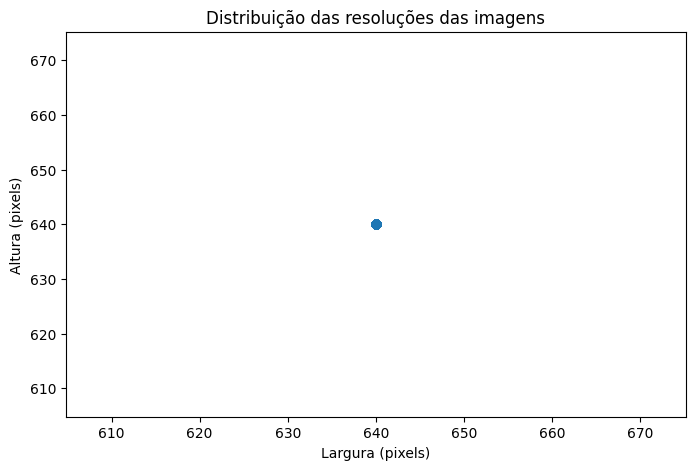

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_resolution["largura"],
    df_resolution["altura"],
    alpha=0.4
)

plt.title("Distribuição das resoluções das imagens")
plt.xlabel("Largura (pixels)")
plt.ylabel("Altura (pixels)")

plt.show()

**EDA 4 — condições de iluminação**

**Calcular brilho médio**

In [27]:
brightness_data = []

for split_name, folder_name in splits.items():

    image_dir = os.path.join(dataset_dir, folder_name, "images")

    for image_file in os.listdir(image_dir):

        if not image_file.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(image_dir, image_file)

        image = cv2.imread(image_path)

        if image is None:
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        brightness = gray.mean()

        brightness_data.append({
            "split": split_name,
            "arquivo": image_file,
            "brilho_medio": brightness
        })

df_brightness = pd.DataFrame(brightness_data)

df_brightness.head()

,split,arquivo,brilho_medio
0,train,frameHRGateDay-10-mp425200_jpg.rf.3cf43905973b...,113.637053
1,train,bm_frame__m1396_jpg.rf.d69f5d9123c7d67313289dc...,116.861331
2,train,frameHRGateDay-10-mp425600_jpg.rf.e4a156452005...,122.245520
3,train,frame_HBHD2400_jpg.rf.c84e15458bcd761295f6b755...,111.548860
4,train,frameHRGateDay-6-mp437000_jpg.rf.db8119c85ffdd...,157.993276


In [28]:
df_brightness["brilho_medio"].describe()

,brilho_medio
count,1736.000000
mean,113.168131
std,18.409351
min,66.250371
25%,102.347056
50%,113.689390
75%,122.107905
max,160.299285


**Histograma de iluminação**

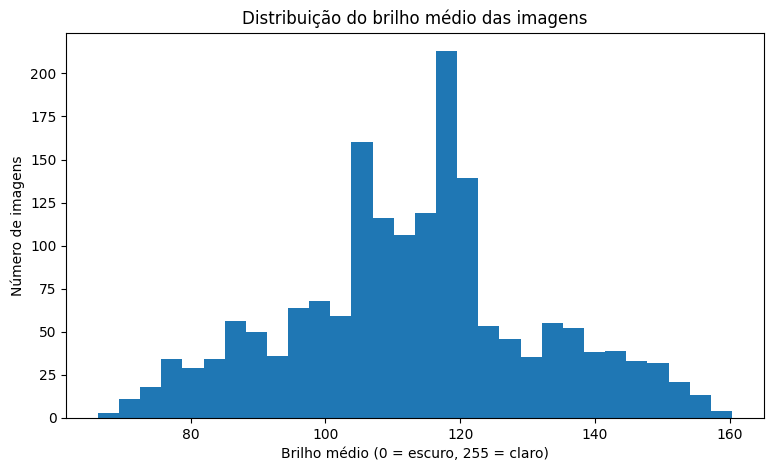

In [29]:
plt.figure(figsize=(9,5))

plt.hist(
    df_brightness["brilho_medio"],
    bins=30
)

plt.title("Distribuição do brilho médio das imagens")
plt.xlabel("Brilho médio (0 = escuro, 255 = claro)")
plt.ylabel("Número de imagens")

plt.show()

**Mostrar imagens mais escuras e mais claras**

In [30]:
def get_image_path(filename):

    for split_name, folder_name in splits.items():

        path = os.path.join(
            dataset_dir,
            folder_name,
            "images",
            filename
        )

        if os.path.exists(path):
            return path

    return None

In [31]:
darkest = df_brightness.sort_values(
    "brilho_medio"
).head(5)

darkest

,split,arquivo,brilho_medio
108,train,frame_KOCHI_441014_jpg.rf.52c1a63a7ade9efe8d0d...,66.250371
546,train,frame_KOCHI_11479_jpg.rf.d09d0674591a249d6747c...,66.449851
1236,train,frame_KOCHI_32456_jpg.rf.fbe20171f2daa10023ea1...,67.970786
689,train,frame_KOCHI_46129_jpg.rf.418120629f407bbfabc4e...,70.643157
794,train,frame_KOCHI_4687_jpg.rf.a349074c8ade4967cd96a9...,70.675569


In [32]:
brightest = df_brightness.sort_values(
    "brilho_medio",
    ascending=False
).head(5)

brightest

,split,arquivo,brilho_medio
312,train,frame_at16140_jpg.rf.dac91c127050cb5e94d0e90a8...,160.299285
4,train,frameHRGateDay-6-mp437000_jpg.rf.db8119c85ffdd...,157.993276
334,train,frameHRGateDay-4-mp418000_jpg.rf.90ea7cb3fd93e...,157.713105
959,train,bm_frame__m1449_jpg.rf.d9383326bbdea7da3aa1dc5...,157.599421
1386,train,frame_av42200_jpg.rf.846d37d0b56fd4a8a469ae3b0...,156.705151


**Criar painel visual**

In [33]:
def show_images(df, title):

    plt.figure(figsize=(15, 8))

    for i, (_, row) in enumerate(df.iterrows()):

        path = get_image_path(row["arquivo"])

        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(df), i + 1)
        plt.imshow(image)
        plt.title(f'{row["brilho_medio"]:.1f}')
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

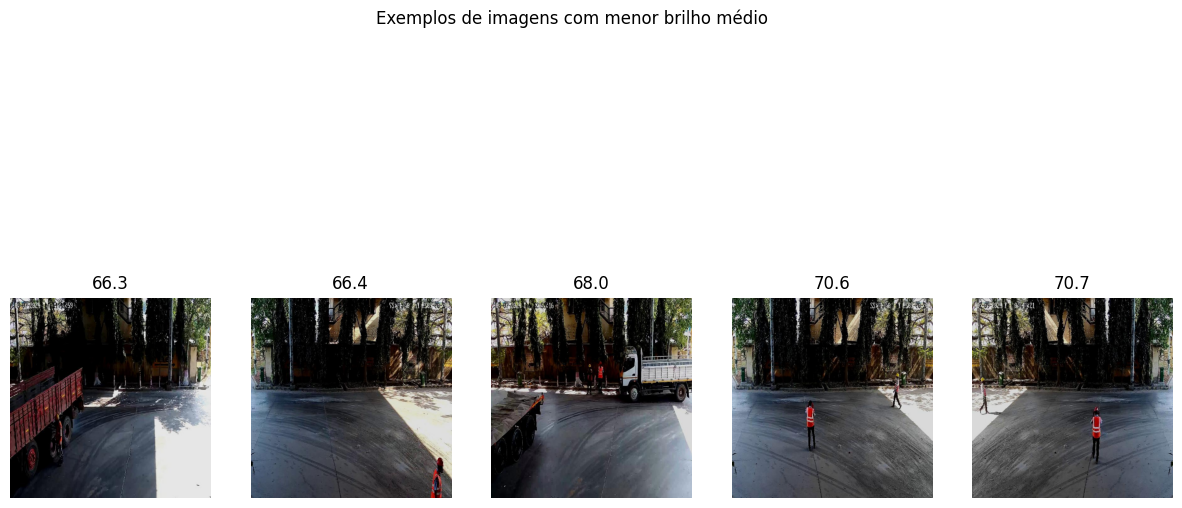

In [34]:
show_images(
    darkest,
    "Exemplos de imagens com menor brilho médio"
)

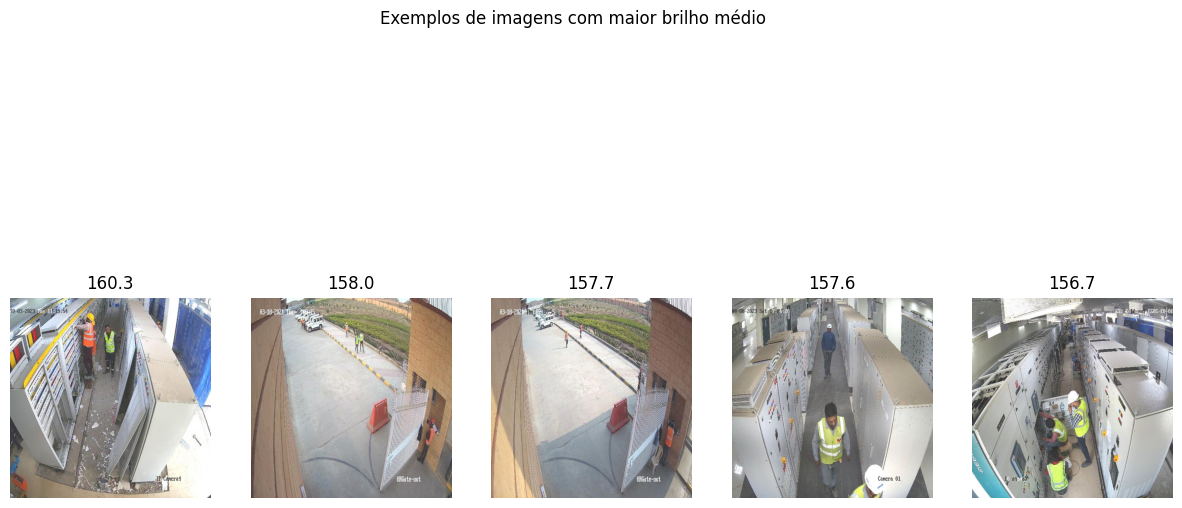

In [35]:
show_images(
    brightest,
    "Exemplos de imagens com maior brilho médio"
)

**EDA 5 — visualizar imagens do dataset**

In [36]:
all_images = []

for split_name, folder_name in splits.items():

    image_dir = os.path.join(dataset_dir, folder_name, "images")

    for image_file in os.listdir(image_dir):

        if image_file.lower().endswith(image_extensions):

            all_images.append(
                os.path.join(image_dir, image_file)
            )

random_images = random.sample(all_images, 9)

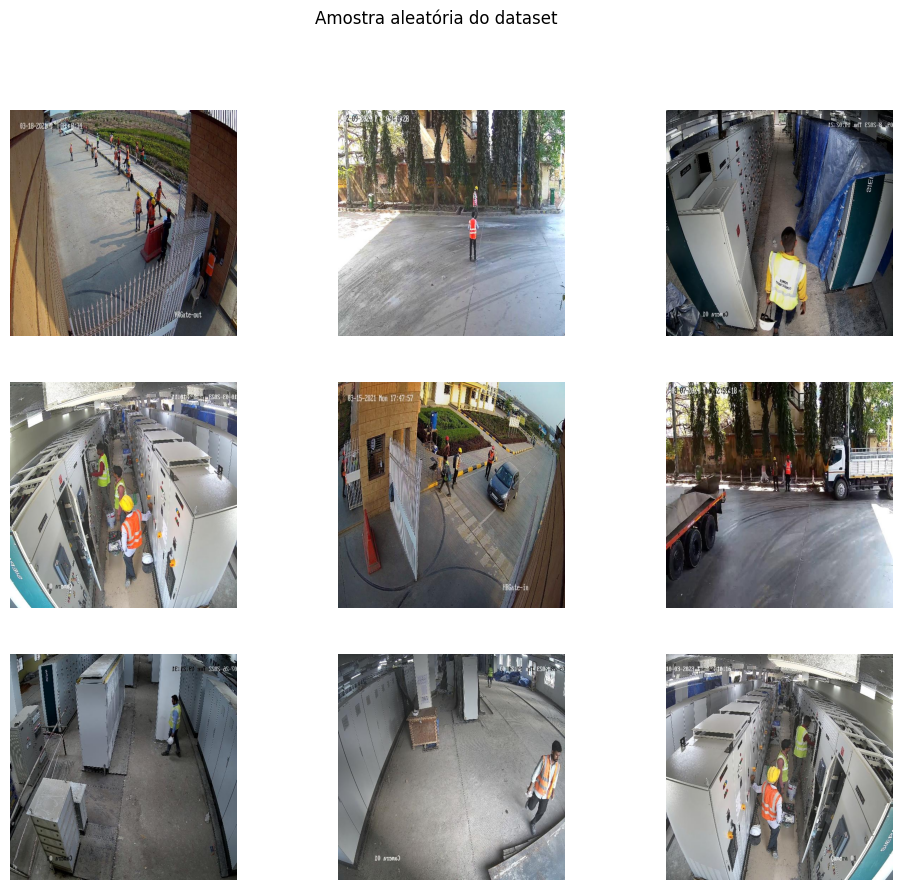

In [37]:
plt.figure(figsize=(12,10))

for i, image_path in enumerate(random_images):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Amostra aleatória do dataset")
plt.show()

**Objetos por imagem**

In [38]:
objects_per_image = []

for split_name, folder_name in splits.items():

    labels_dir = os.path.join(dataset_dir, folder_name, "labels")

    for label_file in os.listdir(labels_dir):

        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as f:
            lines = [
                line for line in f.readlines()
                if line.strip()
            ]

        objects_per_image.append({
            "arquivo": label_file,
            "objetos": len(lines)
        })

df_objects_image = pd.DataFrame(objects_per_image)

df_objects_image["objetos"].describe()

,objetos
count,1736.000000
mean,6.024770
std,3.126713
min,0.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,18.000000


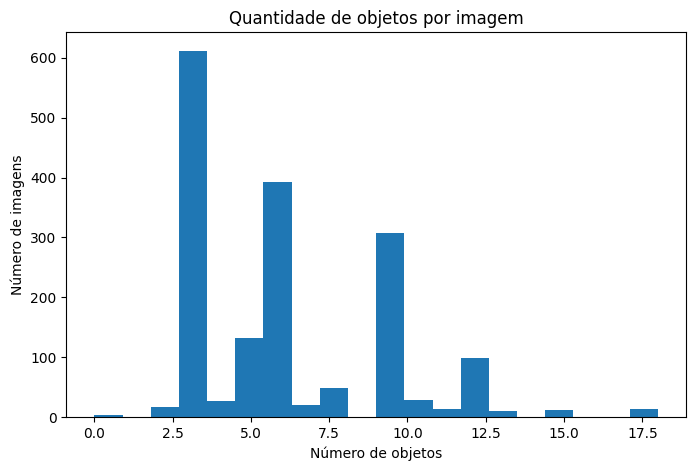

In [39]:
plt.figure(figsize=(8,5))

plt.hist(
    df_objects_image["objetos"],
    bins=20
)

plt.title("Quantidade de objetos por imagem")
plt.xlabel("Número de objetos")
plt.ylabel("Número de imagens")

plt.show()

**EDA 6 — verificar imagens sem anotação**

In [40]:
for split_name, folder_name in splits.items():

    image_dir = os.path.join(dataset_dir, folder_name, "images")
    labels_dir = os.path.join(dataset_dir, folder_name, "labels")

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith(image_extensions)
    ]

    without_label = []

    for image in images:

        label = os.path.splitext(image)[0] + ".txt"

        if not os.path.exists(
            os.path.join(labels_dir, label)
        ):
            without_label.append(image)

    print(
        split_name,
        "-> imagens:",
        len(images),
        "| sem label:",
        len(without_label)
    )

train -> imagens: 1617 | sem label: 0
valid -> imagens: 75 | sem label: 0
test -> imagens: 44 | sem label: 0


**Tabela final do EDA**

In [41]:
eda_resumo = pd.DataFrame({
    "Indicador": [
        "Total de imagens",
        "Imagens de treino",
        "Imagens de validação",
        "Imagens de teste",
        "Total de objetos",
        "Número de classes",
        "Resolução mais comum"
    ],
    "Resultado": [
        len(df_resolution),
        split_counts["train"],
        split_counts["valid"],
        split_counts["test"],
        total_objects,
        len(class_names),
        f"{resolution_counts.iloc[0]['largura']} x {resolution_counts.iloc[0]['altura']}"
    ]
})

eda_resumo

,Indicador,Resultado
0,Total de imagens,1736
1,Imagens de treino,1617
2,Imagens de validação,75
3,Imagens de teste,44
4,Total de objetos,10459
5,Número de classes,5
6,Resolução mais comum,640 x 640


**Verificar imagens sem objetos**

In [42]:
empty_labels = []

for split_name, folder_name in splits.items():

    labels_dir = os.path.join(dataset_dir, folder_name, "labels")

    for label_file in os.listdir(labels_dir):

        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as f:
            content = f.read().strip()

        if content == "":
            empty_labels.append({
                "split": split_name,
                "arquivo": label_file
            })

df_empty = pd.DataFrame(empty_labels)

print("Quantidade de arquivos de anotação vazios:", len(df_empty))

df_empty

Quantidade de arquivos de anotação vazios: 4


,split,arquivo
0,train,frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e66...
1,train,frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb...
2,train,frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874d...
3,valid,frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602...


In [43]:
df_empty

,split,arquivo
0,train,frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e66...
1,train,frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb...
2,train,frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874d...
3,valid,frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602...


In [44]:
for _, row in df_empty.iterrows():

    label_file = row["arquivo"]
    split_name = row["split"]

    image_file = os.path.splitext(label_file)[0]

    # procurar extensão da imagem
    image_path = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        candidate = os.path.join(
            dataset_dir,
            split_name,
            "images",
            image_file + ext
        )

        if os.path.exists(candidate):
            image_path = candidate
            break

    print(split_name, "->", image_path)

train -> /content/PPE_dataset/train/images/frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f.jpg
train -> /content/PPE_dataset/train/images/frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15.jpg
train -> /content/PPE_dataset/train/images/frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47.jpg
valid -> /content/PPE_dataset/valid/images/frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d8ea.jpg


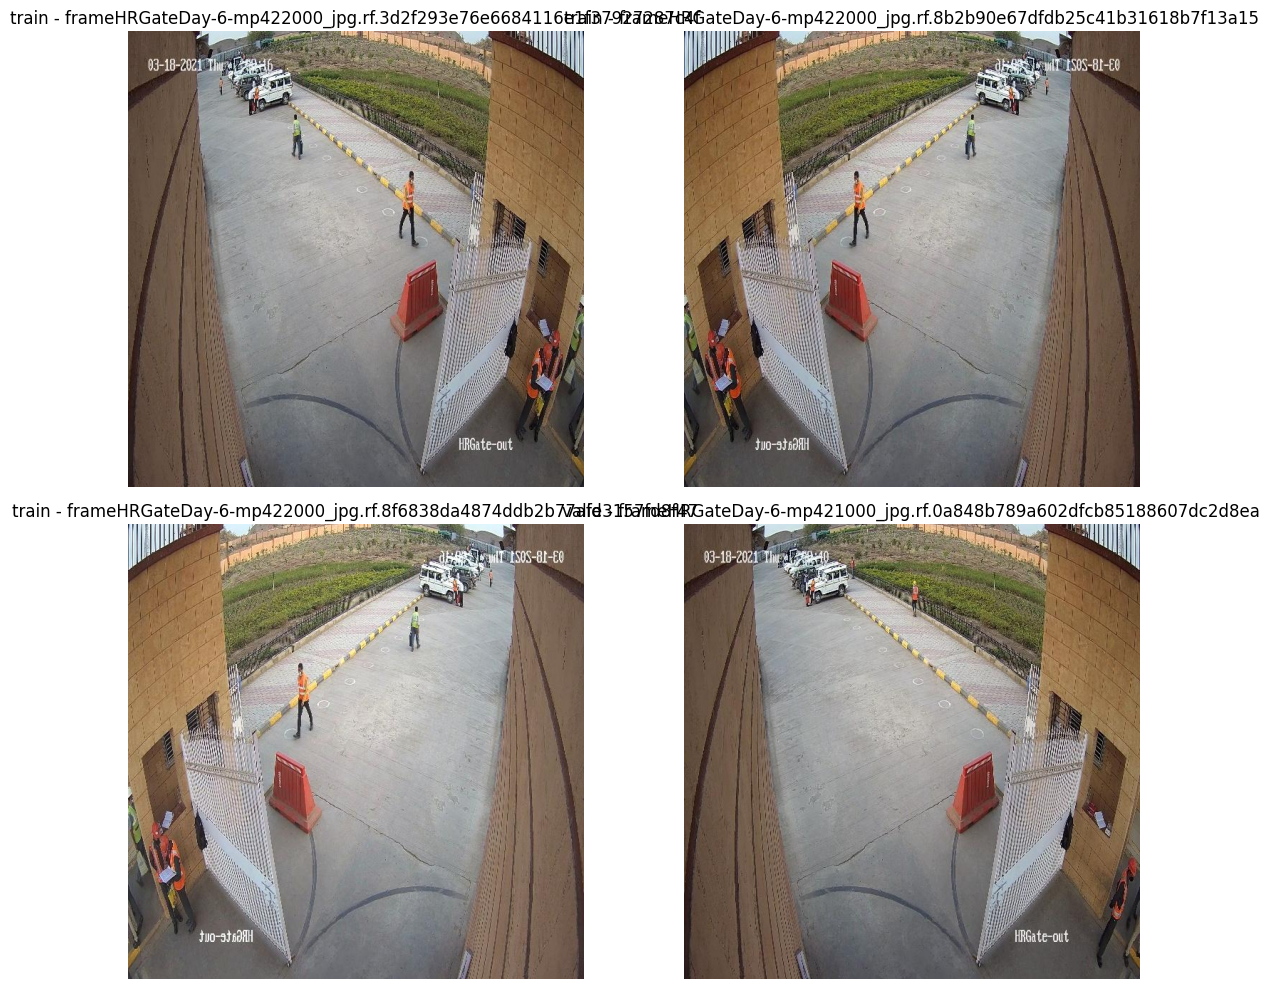

In [45]:
plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(df_empty.iterrows()):

    label_file = row["arquivo"]
    split_name = row["split"]

    image_name = os.path.splitext(label_file)[0]

    image_path = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:

        candidate = os.path.join(
            dataset_dir,
            split_name,
            "images",
            image_name + ext
        )

        if os.path.exists(candidate):
            image_path = candidate
            break

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(f"{split_name} - {image_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
for _, row in df_empty.iterrows():
    print(
        "Conjunto:",
        row["split"],
        "| Label:",
        row["arquivo"]
    )

Conjunto: train | Label: frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f.txt
Conjunto: train | Label: frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15.txt
Conjunto: train | Label: frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47.txt
Conjunto: valid | Label: frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d8ea.txt


In [47]:
df_empty.to_csv(
    "/content/imagens_removidas.csv",
    index=False
)

print("Lista salva.")

Lista salva.


**Cópia limpa**

In [48]:
clean_dataset_dir = "/content/PPE_dataset_clean"

In [49]:
import shutil
import os

clean_dataset_dir = "/content/PPE_dataset_clean"

# Se já existir uma versão anterior, remove para começar limpo
if os.path.exists(clean_dataset_dir):
    shutil.rmtree(clean_dataset_dir)

# Copia o dataset original
shutil.copytree(dataset_dir, clean_dataset_dir)

print("Cópia criada em:")
print(clean_dataset_dir)

Cópia criada em:
/content/PPE_dataset_clean


**Lista dos arquivos problemáticos**

In [50]:
files_to_remove = [
    {
        "split": "train",
        "label": "frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f.txt"
    },
    {
        "split": "train",
        "label": "frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15.txt"
    },
    {
        "split": "train",
        "label": "frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47.txt"
    },
    {
        "split": "valid",
        "label": "frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d8ea.txt"
    }
]

In [51]:
image_extensions = [
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
]

for item in files_to_remove:

    split = item["split"]
    label_file = item["label"]

    base_name = os.path.splitext(label_file)[0]

    label_path = os.path.join(
        clean_dataset_dir,
        split,
        "labels",
        label_file
    )

    image_path = None

    for ext in image_extensions:

        candidate = os.path.join(
            clean_dataset_dir,
            split,
            "images",
            base_name + ext
        )

        if os.path.exists(candidate):
            image_path = candidate
            break

    print("\nConjunto:", split)
    print("Label:", label_path)
    print("Imagem:", image_path)


Conjunto: train
Label: /content/PPE_dataset_clean/train/labels/frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f.txt
Imagem: /content/PPE_dataset_clean/train/images/frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f.jpg

Conjunto: train
Label: /content/PPE_dataset_clean/train/labels/frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15.txt
Imagem: /content/PPE_dataset_clean/train/images/frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15.jpg

Conjunto: train
Label: /content/PPE_dataset_clean/train/labels/frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47.txt
Imagem: /content/PPE_dataset_clean/train/images/frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47.jpg

Conjunto: valid
Label: /content/PPE_dataset_clean/valid/labels/frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d8ea.txt
Imagem: /content/PPE_dataset_clean/valid/images/frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d

**Remover os quatro pares**

In [52]:
removed_files = []

for item in files_to_remove:

    split = item["split"]
    label_file = item["label"]

    base_name = os.path.splitext(label_file)[0]

    label_path = os.path.join(
        clean_dataset_dir,
        split,
        "labels",
        label_file
    )

    image_path = None

    for ext in image_extensions:

        candidate = os.path.join(
            clean_dataset_dir,
            split,
            "images",
            base_name + ext
        )

        if os.path.exists(candidate):
            image_path = candidate
            break

    # Remove label
    if os.path.exists(label_path):
        os.remove(label_path)

    # Remove imagem
    if image_path and os.path.exists(image_path):
        os.remove(image_path)

    removed_files.append({
        "split": split,
        "label": label_file,
        "image": image_path
    })

print("Arquivos removidos:")
for item in removed_files:
    print(item)

Arquivos removidos:
{'split': 'train', 'label': 'frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f.txt', 'image': '/content/PPE_dataset_clean/train/images/frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f.jpg'}
{'split': 'train', 'label': 'frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15.txt', 'image': '/content/PPE_dataset_clean/train/images/frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15.jpg'}
{'split': 'train', 'label': 'frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47.txt', 'image': '/content/PPE_dataset_clean/train/images/frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47.jpg'}
{'split': 'valid', 'label': 'frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d8ea.txt', 'image': '/content/PPE_dataset_clean/valid/images/frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d8ea.jpg'}


In [53]:
for item in files_to_remove:

    split = item["split"]
    label_file = item["label"]

    base_name = os.path.splitext(label_file)[0]

    label_path = os.path.join(
        clean_dataset_dir,
        split,
        "labels",
        label_file
    )

    found_image = False

    for ext in image_extensions:

        image_path = os.path.join(
            clean_dataset_dir,
            split,
            "images",
            base_name + ext
        )

        if os.path.exists(image_path):
            found_image = True
            break

    print(
        base_name,
        "| label existe:",
        os.path.exists(label_path),
        "| imagem existe:",
        found_image
    )

frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f | label existe: False | imagem existe: False
frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15 | label existe: False | imagem existe: False
frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47 | label existe: False | imagem existe: False
frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d8ea | label existe: False | imagem existe: False


**Verificação de labels vazio**

In [54]:
empty_labels_clean = []

for split_name, folder_name in splits.items():

    labels_dir = os.path.join(
        clean_dataset_dir,
        folder_name,
        "labels"
    )

    for label_file in os.listdir(labels_dir):

        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(
            labels_dir,
            label_file
        )

        with open(label_path, "r") as f:
            content = f.read().strip()

        if content == "":
            empty_labels_clean.append({
                "split": split_name,
                "arquivo": label_file
            })

print(
    "Quantidade de arquivos de anotação vazios:",
    len(empty_labels_clean)
)

Quantidade de arquivos de anotação vazios: 0


**Validar quantidades**

In [57]:
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

In [58]:
for split_name, folder_name in splits.items():

    image_dir = os.path.join(
        clean_dataset_dir,
        folder_name,
        "images"
    )

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith(image_extensions)
    ]

    print(
        split_name,
        "->",
        len(images),
        "imagens"
    )

train -> 1614 imagens
valid -> 74 imagens
test -> 44 imagens


**Fechamento EDA**

In [59]:
from collections import Counter
from pathlib import Path

dataset_path = Path("/content/PPE_dataset_clean")

class_names = [
    "person",
    "with-helmet",
    "with-suit",
    "without-helmet",
    "without-suit"
]

counts = Counter()

for split in ["train", "valid", "test"]:

    labels_path = dataset_path / split / "labels"

    for label_file in labels_path.glob("*.txt"):

        with open(label_file, "r") as f:

            for line in f:

                line = line.strip()

                if line:
                    class_id = int(line.split()[0])
                    counts[class_id] += 1


print("Quantidade de objetos por classe:")
print()

for class_id, class_name in enumerate(class_names):

    print(f"{class_name}: {counts[class_id]}")

Quantidade de objetos por classe:

person: 3541
with-helmet: 2466
with-suit: 3101
without-helmet: 1079
without-suit: 272
